#  🚀  **Aircheck Workshop: Data Preprocessing & Analysis** 🧬
Welcome to the **Aircheck Hackaton**!

In this notebook, we will preprocess molecular data and extract meaningful features for machine learning.

---

## **Train Data: DEL-Based Compound Screening on WDR91 Protein**

![](https://drive.google.com/uc?id=1nVHvY7DrSHiMrqCL2DncUioHtFoUg0Gc)

**Reference:** https://pubmed.ncbi.nlm.nih.gov/35535861/



---



## **Test Data: ASMS-Based Compound Screening on WDR91 Protein**
![](https://drive.google.com/uc?id=1o1-_JVUAOD_yEKDozLMXtSOoxTk_Unfq)

**Reference:** https://www.biorxiv.org/content/10.1101/2025.01.17.633682.abstract



---



## **Target protein: WDR91**

WDR91 is a WD40 repeat-containing protein. Proteins in this family act as scaffolds for other proteins to stick to when forming multiprotein complexes WDR domain-containing proteins comprise one of the largest protein families in humans and are involved in a diverse array of cellular networks and diseases.

**look it up on uniprot:** https://www.uniprot.org/uniprotkb/A4D1P6/entry

WDR91 plays a critical role in regulating early-to-late endosomal maturation and trafficking, processes essential for cellular functions such as nutrient uptake, signal transduction, and membrane protein recycling.

**Reference:** https://www.nature.com/articles/nrd.2017.179

▶ **Actives**:  Label= 1      
▶ **Inactives**: Label = 0

![](https://drive.google.com/uc?id=1ID6DfPbbBqH5nouz3FNdkV478ONzAOV3)
**Reference:** Protein–Ligand Docking in the Machine-Learning Era: https://www.mdpi.com/1420-3049/27/14/4568




---



## **RDKit**
RDKit is an open-source cheminformatics toolkit written in C++ with Python bindings. features:
Molecular Representation: Handles molecules using formats like SMILES and InChI.

- **Molecular Descriptors**: Computes features like molecular weight and LogP.
- **Substructure Search**: Identifies specific molecular fragments or patterns.
- **Fingerprints**: Generates molecular fingerprints for similarity and clustering.
- **Visualization**: Creates 2D molecular drawings, integrates with Jupyter.
- **Chemical Reactions**: Simulates reactions and predicts products.
- **3D Operations**: Builds 3D structures and optimizes geometries.

![](https://drive.google.com/uc?id=1hf6GSDQLWzREkPyPmdD81wzZEhUn5_oD)



---



## **🟢 1. Install and Import Dependencies**
In this section, we install the necessary packages for chemical data processing and machine learning.bold text

In [9]:
# Install the requirements:
!pip install pandas numpy lightgbm rdkit
!pip install umap-learn

In [10]:
# Import libraries:
import pandas as pd
import numpy as np
import rdkit
from rdkit.Chem import MolFromSmiles
from rdkit.Chem import AllChem
import os
import seaborn as sns
import umap

## 🟢 **2. Downloading Train & Test Data from Aircheck**
To begin, we need to **download the dataset** from the Aircheck website and upload it to **Google Drive**.

## **2-1- Option A**
**Step 1**: Download the **train dataset** from AIRCHECK website
Go to **Aircheck’s website** and download the train & test data.
  AIRCHECK Website: https://www.aircheck.ai/datasets

![](https://drive.google.com/uc?id=1Bviu4TcSIP5k6MONK_OsyqW9BoCekzzd)


**Step 2**: Download **test data** using this link:
   https://drive.google.com/file/d/1JlgxqbeVcS7Kd5rRZE6_4fE51D9m765q/view?usp=drive_link

<img src="https://drive.google.com/uc?id=1kgK1OiFUeQog3zESFOnQqQzVFMZ1hkzE" width="50%">

**Step 3:** Open **Google Drive**, create a folder named **AircheckWorkshopData**, and upload both datasets to this folder.

In [11]:
from google.colab import drive
drive.mount('/content/drive')
import os

# Define the folder path
folder_path = "/content/drive/My Drive/AircheckWorkshopData"

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created successfully.")
else:
    print(f"Folder '{folder_path}' already exists.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder '/content/drive/My Drive/AircheckWorkshopData' already exists.


**Step 4:** Copy downloaded data to this folder: "/content/drive/My Drive/AircheckData"

**Step 5:** Read the datasets into Pandas DataFrames.

In [12]:
import pandas
TestData_path = '/content/drive/My Drive/AircheckWorkshopData/AircheckWorkshop2025_TestFile.csv'
TrainData_path = '/content/drive/My Drive/AircheckWorkshopData/BalancedTrainset_Aircheck_WDR91_Hitgen_DEL.parquet'

# Load the CSV file into a Pandas DataFrame
df_test = pd.read_csv(TestData_path)
df_train = pd.read_parquet(TrainData_path, engine='pyarrow')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/AircheckWorkshopData/AircheckWorkshop2025_TestFile.csv'



---



## **2-2- Option B:**
**Use the GCP buckets to access the datasets!**

**Step 1:** Set Up Google Cloud SDK in Colab

In [ ]:
from google.colab import auth
auth.authenticate_user()

# Install Google Cloud SDK if not already installed
!pip install --upgrade google-cloud-storage

**Step 2:** Set Up GCP Access

In [ ]:
import os
from google.cloud import storage

# Set your GCP project ID
os.environ["GOOGLE_CLOUD_PROJECT"] = "AircheckWorkshopStudent"

# Set up GCP storage client
client = storage.Client()
bucket_name = "Aircheck-bucket-name"


**Step 3:** Download Files from GCP Bucket

In [8]:
Trainset_GCP_Path=""
Testset_GCP_Path=""
bucket = client.bucket(bucket_name)

blob = bucket.blob(Trainset_GCP_Path)
blob.download_to_filename("BalancedTrainset_Aircheck_WDR91_Hitgen_DEL.parquet")

blob = bucket.blob(Testset_GCP_Path)
blob.download_to_filename("AircheckWorkshop2025_TestFile.csv")

NameError: name 'client' is not defined

**Step 4:** Read the datasets into Pandas DataFrames.

In [7]:
import pandas
TestData_path = "/content/AircheckWorkshop2025_TestFile.csv'
TrainData_path = "/content/BalancedTrainset_Aircheck_WDR91_Hitgen_DEL.parquet"

# Load the CSV file into a Pandas DataFrame
df_test = pd.read_csv(TestData_path)
df_train = pd.read_parquet(TrainData_path, engine='pyarrow')

SyntaxError: unterminated string literal (detected at line 2) (<ipython-input-7-fc5c79e0d522>, line 2)

---

## 🟢 **3. Exploring Train dataset**

In [6]:
# Summary of the trian dataset
df_train.info()

# Columns' names
column_list = df_train.columns.tolist()
print("\nColumns' names: ", column_list)
print("\n")

# First 3 samples of the Test dataset
df_train.head(3)

NameError: name 'df_train' is not defined

In [ ]:
# Anomaly Detection

# Any Nulls?
null_counts = df_train.isnull().sum()
print(", ".join(f"{col}: {count}" for col, count in null_counts.items()))
print("\nThere are no nulls!" if null_counts.sum() == 0 else ", ".join(f"{col}: {count}" for col, count in null_counts.items() if count > 0))

# Any Duplicates?
duplicate_counts = df_train.duplicated().sum()
print("There are no duplicates!" if duplicate_counts == 0 else f"Total Duplicates: {duplicate_counts}")

ID: 0, DEL_ID: 0, DELLabel: 0, RawCount: 0, Target: 0, ECFP4: 0, ECFP6: 0, FCFP4: 0, FCFP6: 0, MACCS: 0, RDK: 0, AVALON: 0, ATOMPAIR: 0, TOPTOR: 0, MW: 0, ALOGP: 0

There are no nulls!
There are no duplicates!


**Let's check it out:**
* How many compounds are in this screen?
* How many of these are enriched?

In [ ]:
rows, cols = df_train.shape
print(f"Rows: {rows}, Columns: {cols}")

# Count occurrences of DELLabel = 0 and DELLabel = 1
count_not_enriched = (df_train['DELLabel'] == 0).sum()
count_enriched = (df_train['DELLabel'] == 1).sum()

# Print results
print(f"Compounds not enriched (DELLabel = 0): {count_not_enriched}")
print(f"Compounds enriched (DELLabel = 1): {count_enriched}")

Rows: 57556, Columns: 16
Compounds not enriched (DELLabel = 0): 28778
Compounds enriched (DELLabel = 1): 28778


Take some time to explore what the different columns mean:


| Field Name   | Data Type | Mode     | Description                                                                 |
|--------------|-----------|----------|-----------------------------------------------------------------------------|
| ID           | Long      | Required | Unique computed ID from DEL_ID concatenating DEL Library ID and Building Block IDs. |
| DEL_ID       | String    | Required | Unique ID of full enumerated DNA-Encoded Library (DEL) compound.            |
| DELLabel        | Integer   | Required | Binary classification label for observed enrichment (0 not enriched, 1 enriched). |
| RawCount     | Integer   | Nullable | The sequence count (enrichment) for the specific target.                    |
| TARGET_ID    | String    | Required | Unique ID of the target.                                                   |
| ECFP4        | Bytes     | Nullable | Count (non-binary) fingerprint generated using Extended Connectivity Fingerprint (ECFP) with radius 2 and 2048 bits. |
| ECFP6        | Bytes     | Nullable | Count (non-binary) fingerprint generated using Extended Connectivity Fingerprint (ECFP) with radius 3 and 2048 bits. |
| FCFP4        | Bytes     | Nullable | Count (non-binary) fingerprint generated using Functional Connectivity Fingerprints (FCFP) with radius 2 and 2048 bits. |
| FCFP6        | Bytes     | Nullable | Count (non-binary) fingerprint generated using Functional Connectivity Fingerprints (FCFP) with radius 3 and 2048 bits. |
| MACCS        | Bytes     | Nullable | FP generated using the Molecular Access System (MACCS).                     |
| RDK          | Bytes     | Nullable | FP generated using the RDKit fingerprint.                                  |
| AVALON       | Bytes     | Nullable | FP generated using the Avalon fingerprint.                                 |
| ATOMPAIR     | Bytes     | Nullable | FP generated using the Atom Pair fingerprint.                               |
| TOPTOR       | Bytes     | Nullable | FP generated using the Topological Torsion fingerprint.                     |
| MW           | Float     | Nullable | Molecular weight of the enumerated DEL rounded to its integer value.        |
| ALOGP        | Float     | Nullable | Calculated LogP of the enumerated DEL rounded to one decimal. Synonymous with ClogP. |



## **3-1- Investigate molecular properties**

**ALOGP:**ALOGP (Atom-based LogP) is a key property in drug discovery that estimates a compound’s lipophilicity, or its ability to dissolve in fats versus water. It predicts the partition coefficient (LogP), which affects drug absorption, permeability, and solubility. A well-balanced LogP value ensures that a drug can efficiently cross biological membranes while remaining soluble enough for proper distribution. In medicinal chemistry, ALOGP is used to optimize drug candidates by improving their bioavailability and reducing potential toxicity.

**Molecular weight:** Molecular weight (MW) is another crucial factor influencing a drug’s pharmacokinetics, including absorption, distribution, metabolism, and excretion. Lower molecular weight compounds tend to have better cell permeability and oral bioavailability, while excessively large molecules may face challenges in diffusion and transport. Lipinski’s Rule of Five recommends an MW below 500 Da for optimal oral drugs, ensuring they can be efficiently absorbed and distributed in the body. Controlling MW helps medicinal chemists design drugs that balance potency, stability, and metabolic efficiency.

In [5]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ALOGP histogram
sns.histplot(data=df_train, x="ALOGP", kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution of ALOGP")

# Plot MW histogram
sns.histplot(data=df_train, x="MW", kde=True, bins=30, ax=axes[1])
axes[1].set_title("Distribution of Molecular Weight")

# Adjust layout
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## **3-2- Labels exploration**

Enrichment has been binarized to 0 (not enriched) and 1 (enriched), but we can also look at the raw counts. Note: It is possible for inactive compounds to have non-zero raw count.

In [ ]:
import matplotlib.pyplot as plt

# Plot the histogram
df_train['DELLabel'].hist(bins=30, edgecolor='black')

# Add labels and title
plt.xlabel('DELLabel')
plt.ylabel('Frequency')
plt.title('Histogram of DELLabel')
# Show the plot
plt.show()

In [ ]:
# Plot raw counts and label of enrichment
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))

# Label 0 plot
sns.histplot(data=df_train[df_train['DELLabel']==0], x="RawCount", bins=50, color='#1f77b4', ax=ax1)
ax1.set_xlim(0, 0.5)
ax1.set_title('Label 0')

# Label 1 plot
sns.histplot(data=df_train[df_train['DELLabel']==1], x="RawCount", bins=50, color='#ff7f0e', ax=ax2)
ax2.set_title('Label 1')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## **3-3- Class imbalance**

This is a very unbalanced data set, a common thing in drug discovery

In [ ]:
# Let's look at how many DEL hits there are
# Calculate the ratio of labels
label_counts = df_train['DELLabel'].value_counts(normalize=True)

# Print the ratio of labels
print(label_counts)

DELLabel
1    0.5
0    0.5
Name: proportion, dtype: float64


## 🟢 **4. Exploring Test dataset**

In [ ]:
# Summary of the test dataset
df_test.info()

# Columns' names
column_list = df_test.columns.tolist()
print("\nColumns' names: ", column_list)
print("\n")

# Number of columns and rows
rows, cols = df_train.shape
print(f"Rows: {rows}, Columns: {cols}")

# First 3 samples of the Test dataset
df_test.head(3)

NameError: name 'df_test' is not defined

**Your turn!**

Add code here to check for anomalies in the test datasets, such as duplicates and null values.

In [ ]:
# Add code here to check for anomalies in the test datasets, such as duplicates and null values.

---

## 🟢 **5. Visualizing Molecular Structures**
Molecules in the dataset are stored as **SMILES** strings. Using **RDKit**, we will:
- Convert **SMILES to molecule objects**.
- Visualize multiple molecules using `Draw.MolsToGridImage()`.
- Check structural diversity in the dataset.

Understanding molecules visually helps interpret **chemical properties**.

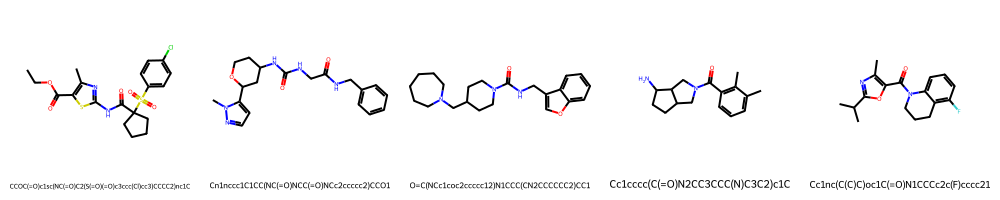

In [ ]:
import random
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Randomly select 5 SMILES from df_test (drop NaNs to avoid errors)
random_smiles = random.sample(df_test['SMILES'].dropna().tolist(), 5)

# Convert SMILES to RDKit Mol objects
mols = [Chem.MolFromSmiles(smiles) for smiles in random_smiles]

# Draw molecules in a row with SMILES as legends
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=random_smiles)

# Display the image
display(img)


---

## 🟢 **6. What is a SMILES String?**

SMILES (Simplified Molecular Input Line Entry System) is a text representation of a molecule's structure using ASCII characters. It encodes the atoms, bonds, rings, and connectivity in a linear format.

## **How Does SMILES Work?**

- **Atoms** are represented by element symbols (e.g., `C` for carbon, `O` for oxygen).
- **Bonds** are represented as:
  - **Single bond**: `-` *(optional)*
  - **Double bond**: `=`
  - **Triple bond**: `#`
- **Branches** are enclosed in parentheses: `CC(O)C` → represents **isopropanol**.
- **Rings** are denoted by numbers: `c1ccccc1` (Benzene ring).
- **Aromaticity** is denoted by lowercase letters:  
  - `c1ccccc1` (aromatic benzene)  
  - `C1CCCCC1` (cyclohexane)
- **Charged atoms** are denoted with `+` or `-`: `[Na+]`, `[O-]`.



In [ ]:
# Generate Canonical SMILES
# To ensure a standardized (canonical) form of a SMILES string:
from rdkit import Chem
mol = Chem.MolFromSmiles("CCO")  # Ethanol
canonical_smiles = Chem.MolToSmiles(mol, canonical=True)

print("Canonical SMILES:", canonical_smiles)

Canonical SMILES: CCO


In [ ]:
# Example:
# Different SMILES for Aspirin (Before Canonicalization)

# Different ways to write Aspirin
smiles_1 = "CC(=O)Oc1ccccc1C(=O)O"   # Common representation
smiles_2 = "O=C(O)c1ccccc1OC(C)=O"   # Rearranged structure

# Convert to canonical SMILES
canonical_1 = Chem.MolToSmiles(Chem.MolFromSmiles(smiles_1), canonical=True)
canonical_2 = Chem.MolToSmiles(Chem.MolFromSmiles(smiles_2), canonical=True)

print("Canonical SMILES 1:", canonical_1)
print("Canonical SMILES 2:", canonical_2)
print("Same molecule?", canonical_1 == canonical_2)

Canonical SMILES 1: CC(=O)Oc1ccccc1C(=O)O
Canonical SMILES 2: CC(=O)Oc1ccccc1C(=O)O
Same molecule? True


## **Where do we get the SMILES?**

If you have a MOL file (common chemical format) or  SDF file (Structure Data File containing multiple molecules), you can read it and get the SMILES:


### **What is a MOL File?**
A MOL file (Molecular Structure File) is a chemical file format that stores 3D structural information about a molecule, including atoms, bonds, connectivity, and coordinates.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Define a simple SMILES (Ethanol)
smiles = "CCO"

# Convert SMILES to an RDKit molecule object
mol = Chem.MolFromSmiles(smiles)

# Save it as a MOL file
mol_file_path = "ethanol.mol"
Chem.MolToMolFile(mol, mol_file_path)

# Display the molecule image
if mol:
    img = Draw.MolToImage(mol)
    display(img)

    # Read and print the MOL file content
    with open(mol_file_path, "r") as file:
        mol_content = file.read()
    print("\nMOL File Content:\n")
    print(mol_content)
else:
    print("Error: Invalid SMILES")

---

## 🟢 **7. Extracting Molecular Fingerprints**

#### **Usage in Drug Discovery**

- **Similarity Searches**: Finding compounds similar to a known active molecule.
- **QSAR Modeling**: Predicting biological activity based on chemical structure.
- **Machine Learning for Drug Discovery**: Used as features in models to classify or predict compound properties.


## **Morgan Fingerprints**

Morgan fingerprints are a type of circular (or radial) molecular fingerprint used in cheminformatics for representing chemical structures numerically. They are generated using the Extended Connectivity Fingerprint (ECFP) algorithm, which encodes molecular features based on the connectivity of atoms within a given radius.

#### **Types of Circular Fingerprints**

#### **1. Extended-Connectivity Fingerprints (ECFP)**
- Encode molecular features by focusing on the structural identity of atoms, such as atomic number, bonds, and connectivity.


#### **2. Functional-Class Fingerprints (FCFP)**
- Encode molecular features by focusing on the **functional roles** of atoms (e.g., hydrogen-bond donors, acceptors, aromaticity, charge).

![](https://drive.google.com/uc?id=1Ao9J23R_YOvvQxtSJDLCYf0tAfZvjaNc)


Reference: Glen, R.C.et all, 2006. Circular fingerprints: flexible molecular descriptors with applications from physical chemistry to ADME.


Generated Fingerprints (128-bit) - Bit Vectors:
Fingerprint Type                                                                                           Bit Vector
           ECFP4 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
           ECFP6 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
           FCFP4 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
           FCFP6 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...

Generated Fingerprints (128-bit) - Binary Representation:
Fingerprint Type                                                                                        Binary String
           ECFP4 0010000000000000000000000000000001000011000000000000000000000000000000000000000010000000000000100...
           ECFP6 0010000000000000000000000000000001000011000000000

[19:11:13] DEPRECATION WARNING: please use MorganGenerator
[19:11:13] DEPRECATION WARNING: please use MorganGenerator
[19:11:13] DEPRECATION WARNING: please use MorganGenerator
[19:11:13] DEPRECATION WARNING: please use MorganGenerator


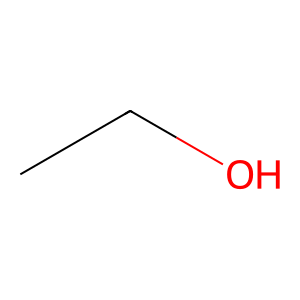

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from IPython.display import display

# Define a simple SMILES (Ethanol)
smiles = "CCO"

# Convert SMILES to an RDKit molecule object
mol = Chem.MolFromSmiles(smiles)

# Define fingerprint size (128-bit)
fp_size = 128

# Generate fingerprints
ecfp4 = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=fp_size)  # ECFP4
ecfp6 = GetMorganFingerprintAsBitVect(mol, radius=3, nBits=fp_size)  # ECFP6
fcfp4 = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=fp_size, useFeatures=True)  # FCFP4
fcfp6 = GetMorganFingerprintAsBitVect(mol, radius=3, nBits=fp_size, useFeatures=True)  # FCFP6

# Convert fingerprints to binary strings
def fingerprint_to_binary(fp):
    return "".join(str(int(b)) for b in fp)

# Create a DataFrame for tabular representation of bit vectors
bit_vector_data = {
    "Fingerprint Type": ["ECFP4", "ECFP6", "FCFP4", "FCFP6"],
    "Bit Vector": [list(ecfp4), list(ecfp6), list(fcfp4), list(fcfp6)]
}
df_bit_vectors = pd.DataFrame(bit_vector_data)

# Print the table for bit vectors
print("\nGenerated Fingerprints (128-bit) - Bit Vectors:")
print(df_bit_vectors.to_string(index=False, max_colwidth=100))

# Create a DataFrame for binary strings
binary_data = {
    "Fingerprint Type": ["ECFP4", "ECFP6", "FCFP4", "FCFP6"],
    "Binary String": [
        fingerprint_to_binary(ecfp4),
        fingerprint_to_binary(ecfp6),
        fingerprint_to_binary(fcfp4),
        fingerprint_to_binary(fcfp6),
    ],
}
df_binary = pd.DataFrame(binary_data)

# Print the table for binary strings separately
print("\nGenerated Fingerprints (128-bit) - Binary Representation:")
print(df_binary.to_string(index=False, max_colwidth=100))

# Display the molecule
if mol:
    img = Draw.MolToImage(mol)
    display(img)
else:
    print("Error: Invalid SMILES")



---

## 🟢 **8. Computing Molecular Distance & Similarity**

### **Tanimoto Similarity in Molecular Fingerprints*

- **Mol A and Mol B**: Each molecule is represented as a binary fingerprint, where each bit indicates the presence (`1`) or absence (`0`) of a structural feature.
- **Colored Blocks**:
  - **Red**: Features present in Mol A but not in Mol B.
  - **Blue**: Features present in Mol B but not in Mol A.
  - **Black**: Features shared between Mol A and Mol B (common features).

![](https://drive.google.com/uc?id=1gS61UXR7aD6MwolB3NXqjFD-xWiuDjvk)


### **8-1- Convert and Binarize data**

In [ ]:
import numpy as np
import random
import pandas as pd
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Draw
from IPython.display import display, HTML

# Function to process fingerprint data
def process_data(X, column_name):
    """Split comma-separated fingerprint data into separate numeric columns and binarize."""
    X_split = X[column_name].str.split(',', expand=True)
    X_split = X_split.apply(pd.to_numeric, errors='coerce')

    # Binarization: Convert values > 0 to 1, else 0
    X_binarized = (X_split > 0).astype(int)

    X_binarized.columns = [f'{column_name}_{i}' for i in range(X_binarized.shape[1])]
    return X_binarized

# Convert ECFP4 fingerprints to binarized format
df_test_processed = process_data(df_test, 'ECFP4')

### **8-2- Check the similarity of random test data**

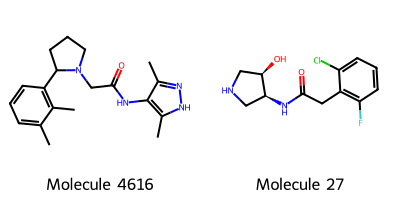

In [ ]:

# Randomly select two different indices
n = df_test.shape[0]
index1, index2 = random.sample(range(n), 2)

# Get selected fingerprints
fp1, fp2 = df_test_processed.iloc[index1].values, df_test_processed.iloc[index2].values

# Compute Tanimoto similarity
common = np.logical_and(fp1, fp2).sum()
total = np.logical_or(fp1, fp2).sum()
tanimoto_sim = common / total if total > 0 else 0.0

# Check if SMILES column exists and convert molecules
if 'SMILES' in df_test.columns:
    mol1, mol2 = Chem.MolFromSmiles(df_test.iloc[index1]['SMILES']), Chem.MolFromSmiles(df_test.iloc[index2]['SMILES'])

    # Draw molecules side by side
    img = Draw.MolsToGridImage([mol1, mol2], molsPerRow=2, subImgSize=(200, 200),
                               legends=[f"Molecule {index1}", f"Molecule {index2}"], useSVG=True)
    display(img)

# Display similarity score
display(HTML(f'<h3>Tanimoto Similarity between Molecule {index1} and {index2}: {tanimoto_sim:.4f}</h3>'))


### **8-3- Compute the similarity between test data and train data:**

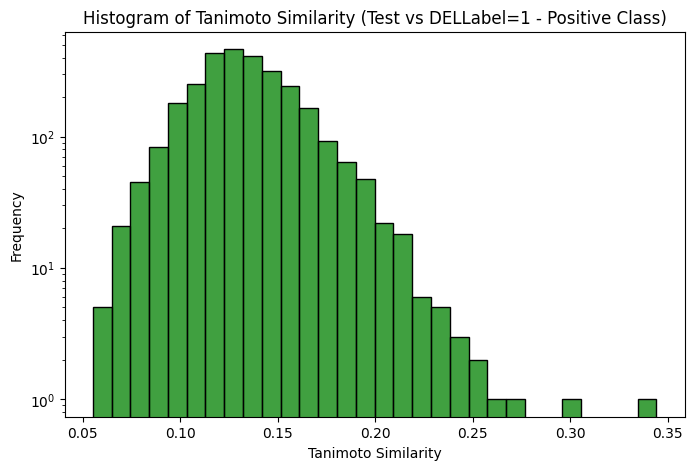

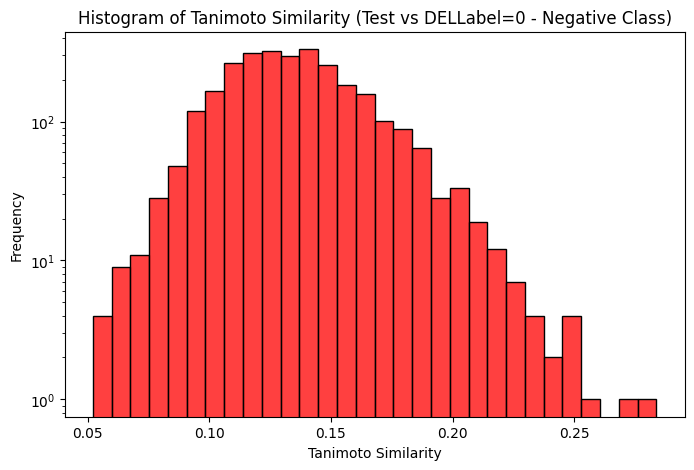

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to split comma-separated fingerprint data into separate numeric columns and binarize.
def process_data(X, column_name):
    """Split comma-separated fingerprint data into separate numeric columns and binarize."""
    X_split = X[column_name].str.split(',', expand=True)
    X_split = X_split.apply(pd.to_numeric, errors='coerce')

    # Binarization: Convert values > 0 to 1, else 0
    X_binarized = (X_split > 0).astype(int)

    X_binarized.columns = [f'{column_name}_{i}' for i in range(X_binarized.shape[1])]
    return X_binarized

# Define fraction of data to sample
sample_frac = 0.01  # 1% of each class

# Sample equal number of positive and negative cases from train dataset
df_train_pos = df_train[df_train['DELLabel'] == 1].sample(frac=sample_frac, random_state=42)
df_train_neg = df_train[df_train['DELLabel'] == 0].sample(frac=sample_frac, random_state=42)

# Ensure we sample equal number from both classes
min_samples = min(len(df_train_pos), len(df_train_neg))
df_train_pos = df_train_pos.sample(n=min_samples, random_state=42)
df_train_neg = df_train_neg.sample(n=min_samples, random_state=42)

# Combine positive and negative samples to form the final train dataset
df_train_sampled = pd.concat([df_train_pos, df_train_neg]).sample(frac=1, random_state=42)  # Shuffle after combining

# Sample test dataset
df_test_sampled = df_test.sample(frac=0.001, random_state=42).copy()

# Convert ECFP4 fingerprints into binarized features
df_test_fps = process_data(df_test_sampled, 'ECFP4')
df_train_pos_fps = process_data(df_train_pos, 'ECFP4')
df_train_neg_fps = process_data(df_train_neg, 'ECFP4')

# Function to compute Tanimoto similarity (after binarization)
def compute_tanimoto_similarity(test_fp, train_fps):
    """Compute Tanimoto similarity between a single binarized test fingerprint and a list of binarized train fingerprints."""
    test_fp = test_fp.values.reshape(1, -1)
    train_fps = train_fps.values
    dot_product = np.dot(train_fps, test_fp.T).flatten()

    sum_test = test_fp.sum()
    sum_train = train_fps.sum(axis=1)

    denominator = sum_test + sum_train - dot_product

    # Handle zero division: If denominator is zero, assign similarity as 0.0
    similarity = np.where(denominator == 0, 0.0, dot_product / denominator)

    return similarity.tolist()

# Compute similarity between test and positive (DELLabel=1) train data
similarities_pos = [
    compute_tanimoto_similarity(test_fp, df_train_pos_fps)
    for _, test_fp in df_test_fps.iterrows()
]

# Compute similarity between test and negative (DELLabel=0) train data
similarities_neg = [
    compute_tanimoto_similarity(test_fp, df_train_neg_fps)
    for _, test_fp in df_test_fps.iterrows()
]

# Flatten the lists for visualization
similarities_pos_flat = [sim for sublist in similarities_pos for sim in sublist]
similarities_neg_flat = [sim for sublist in similarities_neg for sim in sublist]

# Plot histogram for test vs. positive class (DELLabel=1)
plt.figure(figsize=(8, 5))
sns.histplot(similarities_pos_flat, bins=30, kde=False, color='green')
plt.yscale("log")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Histogram of Tanimoto Similarity (Test vs DELLabel=1 - Positive Class)")
plt.show()

# Plot histogram for test vs. negative class (DELLabel=0)
plt.figure(figsize=(8, 5))
sns.histplot(similarities_neg_flat, bins=30, kde=False, color='red')
plt.yscale("log")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Histogram of Tanimoto Similarity (Test vs DELLabel=0 - Negative Class)")
plt.show()


---

## 🟢 **9. Drawing UMAP Visualizations**
Universal Manifold Approximation (UMAP) is a fast, scalable dimensionality reduction method that preserves both local and global data structure. It is widely used for clustering, classification, and visualization in fields like bioinformatics and machine learning.

**Key Features:**
- Preserves structure better than PCA and t-SNE
- Scales efficiently to large datasets
- Faster than t-SNE with high-quality embeddings
- Versatile for images, text, and biological data

**UMAP helps in:**
- Reducing high-dimensional fingerprint data to 2D.
- Visualizing clusters of similar molecules.
- Identifying outliers and relationships.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


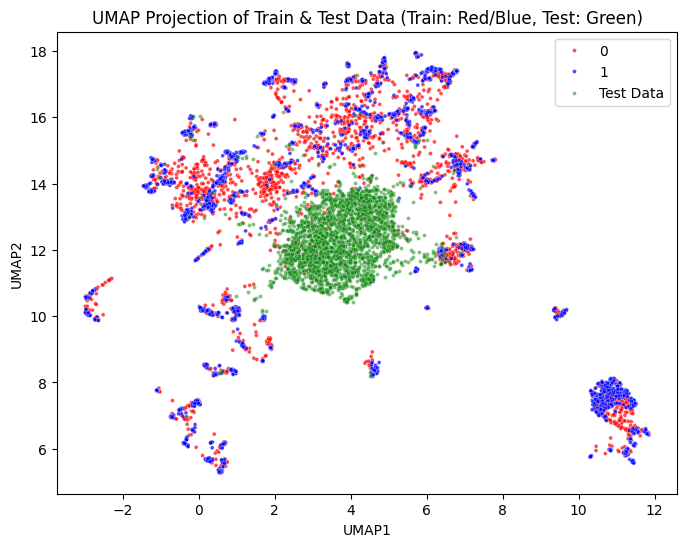

In [ ]:
import numpy as np
import pandas as pd
import umap
import seaborn as sns
import matplotlib.pyplot as plt

# Select 2500 samples from each DELLabel (balanced training set)
df_train_0 = df_train[df_train['DELLabel'] == 0].sample(n=2500, random_state=42)
df_train_1 = df_train[df_train['DELLabel'] == 1].sample(n=2500, random_state=42)

# Combine to form a balanced training dataset
df_train_balanced = pd.concat([df_train_0, df_train_1])

# Randomly select 2500 samples from test data
df_test_sampled = df_test.sample(n=2500, random_state=42)

# Convert ECFP4 strings to lists
X_train = np.array([list(map(int, s.split(','))) for s in df_train_balanced["ECFP4"]])
X_test = np.array([list(map(int, s.split(','))) for s in df_test_sampled["ECFP4"]])

# Combine train and test before fitting UMAP
X_combined = np.vstack([X_train, X_test])

# Prepare UMAP and fit on the full dataset
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric="jaccard",
    random_state=42
)
embedding_combined = umap_model.fit_transform(X_combined)

# Convert to DataFrame
df_combined = pd.DataFrame(embedding_combined, columns=['UMAP1', 'UMAP2'])

# Separate train and test embeddings
df_train_emb = df_combined.iloc[:len(X_train)].copy()
df_test_emb = df_combined.iloc[len(X_train):].copy()

# Assign labels for train data
df_train_emb['DELLabel'] = df_train_balanced['DELLabel'].values  # Keep balanced labels

# Plot train data first (colored by DELLabel: 0=Red, 1=Blue)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_train_emb, x='UMAP1', y='UMAP2', hue='DELLabel', s=8, palette={0: 'red', 1: 'blue'}, alpha=0.7)

# Plot test data separately in green
sns.scatterplot(data=df_test_emb, x='UMAP1', y='UMAP2', color='green', s=8, label='Test Data', alpha=0.5)

# Final plot settings
plt.title('UMAP Projection of Train & Test Data (Train: Red/Blue, Test: Green)')
plt.legend()
plt.show()

---

## 🟢 **10. Feature Selection**
It is possible that not all fingerprint bits or descriptors contribute meaningfully to the model. Some features may:

- **Have very low variance** → These features are almost constant across molecules and don’t provide useful information.
- **Are redundant** → Some features are highly correlated with others and can be removed without losing information.

### Why Compute Feature Variance?
- **Remove Low-Variance Features** → These features don’t change much and won’t help
the model.
- **Select the Most Relevant Features** → Features with high variance tend to capture useful molecular properties.

The threshold for **low variance** depends on the **scale of the data** and the **domain of the problem**

<ipython-input-32-ecc7da5bbcba>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fingerprint Type', y='Variance', data=feature_variance_df, palette='viridis')


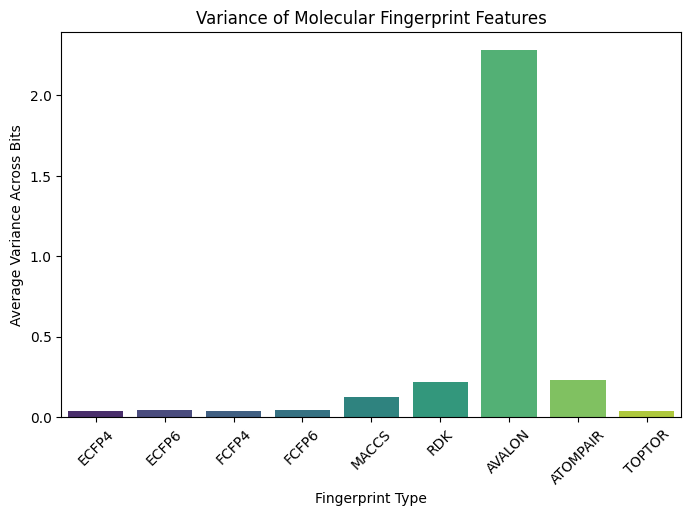

Original Features: 9
Features Retained After Variance Filtering: 9

Retained Features:
 ['ECFP4', 'ECFP6', 'FCFP4', 'FCFP6', 'MACCS', 'RDK', 'AVALON', 'ATOMPAIR', 'TOPTOR']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to process fingerprint columns by splitting comma-separated values into numeric columns
def process_data(X, column_name):
    """Split comma-separated fingerprint data into separate numeric columns."""
    X_split = X[column_name].str.split(',', expand=True)
    X_split = X_split.apply(pd.to_numeric, errors='coerce')  # Convert to numeric values
    return X_split

# List of fingerprint column names
fingerprint_columns = ['ECFP4', 'ECFP6', 'FCFP4','FCFP6', 'MACCS','RDK','AVALON','ATOMPAIR','TOPTOR']

df_test_sampled = df_test.sample(n=250, random_state=42)

# Process each fingerprint column separately and compute variance
feature_variances = {}
for col in fingerprint_columns:
    processed_fps = process_data(df_test_sampled, col)  # Process the column
    feature_variances[col] = processed_fps.var().mean()  # Compute the average variance of its bits

# Convert the variance dictionary to a DataFrame for visualization
feature_variance_df = pd.DataFrame(feature_variances.items(), columns=['Fingerprint Type', 'Variance'])

# Plot feature variance across fingerprint types
plt.figure(figsize=(8, 5))
sns.barplot(x='Fingerprint Type', y='Variance', data=feature_variance_df, palette='viridis')
plt.ylabel("Average Variance Across Bits")
plt.xlabel("Fingerprint Type")
plt.title("Variance of Molecular Fingerprint Features")
plt.xticks(rotation=45)
plt.show()

# Apply variance threshold to filter out low-variance fingerprints
threshold = 0.01  # Define the minimum variance threshold
selected_fingerprints = feature_variance_df[feature_variance_df['Variance'] > threshold]['Fingerprint Type'].tolist()

# Retain only informative fingerprint types
df_test_filtered = df_test_sampled[selected_fingerprints]

# Print summary
print(f"Original Features: {len(fingerprint_columns)}")
print(f"Features Retained After Variance Filtering: {len(selected_fingerprints)}")
print("\nRetained Features:\n", selected_fingerprints)



---

## 🟢 **11. Sparcity**

## 📌 Understanding Low Variance and Sparsity in Feature Selection

Sparsity can change the game in feature selection:
- Some features with high sparsity may correlate strongly with important molecular properties (e.g., bioactivity, toxicity).
- Variance filtering alone is not enough—we also need feature importance methods (e.g., Random Forest, SHAP values).




<ipython-input-33-8192817e5184>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fingerprint Type', y='Sparsity', data=feature_sparsity_df, palette='magma')


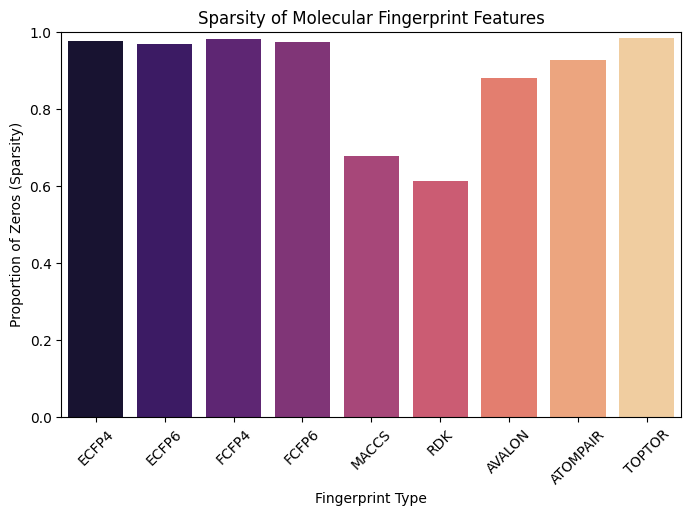

Computed sparsity for 9 fingerprint types.

Feature Sparsity:
   Fingerprint Type  Sparsity
0            ECFP4  0.977129
1            ECFP6  0.969437
2            FCFP4  0.981971
3            FCFP6  0.974357
4            MACCS  0.677749
5              RDK  0.612719
6           AVALON  0.880437
7         ATOMPAIR  0.928713
8           TOPTOR  0.984014


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to process fingerprint columns by splitting comma-separated values into numeric columns
def process_data(X, column_name):
    """Split comma-separated fingerprint data into separate numeric columns."""
    X_split = X[column_name].str.split(',', expand=True)
    X_split = X_split.apply(pd.to_numeric, errors='coerce')  # Convert to numeric values
    return X_split

# List of fingerprint column names
fingerprint_columns = ['ECFP4', 'ECFP6', 'FCFP4', 'FCFP6', 'MACCS', 'RDK', 'AVALON', 'ATOMPAIR', 'TOPTOR']

# Sample 250 molecules from df_test
df_test_sampled = df_test.sample(n=250, random_state=42)

# Process each fingerprint column separately and compute sparsity
feature_sparsity = {}
for col in fingerprint_columns:
    processed_fps = process_data(df_test_sampled, col)  # Process the column
    sparsity = (processed_fps == 0).mean().mean()  # Compute sparsity as the proportion of zeros
    feature_sparsity[col] = sparsity

# Convert the sparsity dictionary to a DataFrame for visualization
feature_sparsity_df = pd.DataFrame(feature_sparsity.items(), columns=['Fingerprint Type', 'Sparsity'])

# Plot feature sparsity across fingerprint types
plt.figure(figsize=(8, 5))
sns.barplot(x='Fingerprint Type', y='Sparsity', data=feature_sparsity_df, palette='magma')
plt.ylabel("Proportion of Zeros (Sparsity)")
plt.xlabel("Fingerprint Type")
plt.title("Sparsity of Molecular Fingerprint Features")
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Sparsity is between 0 and 1
plt.show()

# Print summary
print(f"Computed sparsity for {len(fingerprint_columns)} fingerprint types.")
print("\nFeature Sparsity:\n", feature_sparsity_df)




---



# ✅ **Next Steps**
Now that we have a **clean dataset**, we are ready to move on to **Machine Learning!** 🎯